In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/ml_dataset.csv")

df.head()

,Year,Rank,Branch,Category,Round,Domicile,TotalCandidates,TotalSeats,BranchSeats,Label,RankPercentile,SeatShare
0,2014.0,78121,BT,UR/X/OP,R1,Y,1356000.0,30.0,2.0,1,0.942389,0.066667
1,2014.0,78389,BT,UR/X/OP,R1,Y,1356000.0,30.0,2.0,1,0.942191,0.066667
2,2014.0,78658,BT,UR/X/OP,R1,Y,1356000.0,30.0,2.0,1,0.941993,0.066667
3,2014.0,78927,BT,UR/X/OP,R1,Y,1356000.0,30.0,2.0,1,0.941794,0.066667
4,2014.0,79196,BT,UR/X/OP,R1,Y,1356000.0,30.0,2.0,1,0.941596,0.066667


In [3]:
df.shape

(75647, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75647 entries, 0 to 75646
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             75647 non-null  float64
 1   Rank             75647 non-null  int64  
 2   Branch           75647 non-null  object 
 3   Category         75647 non-null  object 
 4   Round            75647 non-null  object 
 5   Domicile         75647 non-null  object 
 6   TotalCandidates  75647 non-null  float64
 7   TotalSeats       75634 non-null  float64
 8   BranchSeats      75647 non-null  float64
 9   Label            75647 non-null  int64  
 10  RankPercentile   75647 non-null  float64
 11  SeatShare        75634 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 6.9+ MB


In [5]:
df.describe()

,Year,Rank,TotalCandidates,TotalSeats,BranchSeats,Label,RankPercentile,SeatShare
count,75647.000000,7.564700e+04,7.564700e+04,75634.000000,75647.000000,75647.000000,75647.000000,75634.000000
mean,2020.543564,3.603344e+05,1.177620e+06,72.468890,6.455920,0.615385,0.691772,0.107494
std,3.465506,2.996003e+05,1.960349e+05,40.329308,8.681899,0.486507,0.249260,0.136775
min,2014.000000,2.000000e+00,9.055900e+05,1.000000,1.000000,0.000000,0.000000,0.006369
25%,2018.000000,1.360280e+05,1.020000e+06,41.000000,1.000000,0.000000,0.544280,0.028302
50%,2021.000000,2.440380e+05,1.147125e+06,63.000000,3.000000,1.000000,0.791180,0.055556
75%,2024.000000,5.215165e+05,1.415110e+06,104.000000,7.000000,1.000000,0.883700,0.125000
max,2025.000000,1.569201e+06,1.475103e+06,157.000000,97.000000,1.000000,0.999999,2.771429


In [6]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import joblib

categorical_cols = [
    "Branch",
    "Category",
    "Round",
    "Domicile"
]



ohe = OneHotEncoder(

    sparse_output=False,
    handle_unknown="ignore",
    drop=None
)

# ------------------------------------------------
# Encode categorical features
# ------------------------------------------------

encoded_array = ohe.fit_transform(
    df[categorical_cols]
)

# ------------------------------------------------
# Create encoded dataframe
# ------------------------------------------------

encoded_df = pd.DataFrame(

    encoded_array,

    columns=ohe.get_feature_names_out(
        categorical_cols
    )
)

# ------------------------------------------------
# Reset indexes
# ------------------------------------------------

df = df.reset_index(drop=True)

encoded_df = encoded_df.reset_index(drop=True)

# ------------------------------------------------
# Drop original categorical columns
# ------------------------------------------------

df = df.drop(columns=categorical_cols)

# ------------------------------------------------
# Merge encoded columns
# ------------------------------------------------

df = pd.concat(
    [df, encoded_df],
    axis=1
)

# ------------------------------------------------
# OPTIONAL:
# Remove Domicile_N
# because AI + Y already enough
# ------------------------------------------------

if "Domicile_N" in df.columns:
    df = df.drop(columns=["Domicile_N"])

# ------------------------------------------------
# Save encoder
# ------------------------------------------------

joblib.dump(
    ohe,
    "../backend/app/models/onehot_encoder.pkl"
)

print("✅ One Hot Encoding Completed Successfully")

print("Final Shape:", df.shape)

✅ One Hot Encoding Completed Successfully
Final Shape: (75647, 98)


In [8]:
print(df.columns.tolist())

['Year', 'Rank', 'TotalCandidates', 'TotalSeats', 'BranchSeats', 'Label', 'RankPercentile', 'SeatShare', 'Branch_AI', 'Branch_AIAIDS', 'Branch_AIML', 'Branch_AIR', 'Branch_AUTO', 'Branch_AUTO-F.W.', 'Branch_AUTO-FW', 'Branch_BT', 'Branch_BT-F.W.', 'Branch_BT-FW', 'Branch_CE', 'Branch_CE-F.W.', 'Branch_CE-FW', 'Branch_CHEM', 'Branch_CHEM-F.W.', 'Branch_CHEM-FW', 'Branch_CSBS', 'Branch_CSD', 'Branch_CSE', 'Branch_CSE-F.W.', 'Branch_CSE-FW', 'Branch_CST', 'Branch_EACE', 'Branch_ECE', 'Branch_ECE-F.W.', 'Branch_ECE-FW', 'Branch_EE', 'Branch_EE-F.W.', 'Branch_EE-FW', 'Branch_EEIOT', 'Branch_ET', 'Branch_ET-F.W.', 'Branch_ET-FW', 'Branch_IT', 'Branch_IT-F.W.', 'Branch_IT-FW', 'Branch_ITAIAR', 'Branch_ITIOT', 'Branch_MAC', 'Branch_MECH', 'Branch_MECH-F.W.', 'Branch_MECH-FW', 'Category_EWS', 'Category_EWS/S/M', 'Category_EWS/X/F', 'Category_EWS/X/M', 'Category_F.W./X/OP', 'Category_FW', 'Category_FW/OP', 'Category_JKM', 'Category_JKM/X/OP', 'Category_JKR', 'Category_OBC/D/OP', 'Category_OBC/FF

In [9]:
feature_cols = [

    col for col in df.columns

    if col != "Label"
]


In [10]:
X = df[feature_cols]

y = df["Label"]

In [11]:
X

,Year,Rank,TotalCandidates,TotalSeats,BranchSeats,RankPercentile,SeatShare,Branch_AI,Branch_AIAIDS,Branch_AIML,...,Category_UR/S/OP,Category_UR/X/F,Category_UR/X/M,Category_UR/X/OP,Round_INTERNAL,Round_R1,Round_R1_Upgrade,Round_R2,Domicile_AI,Domicile_Y
0,2014.0,78121,1356000.0,30.0,2.0,0.942389,0.066667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2014.0,78389,1356000.0,30.0,2.0,0.942191,0.066667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2014.0,78658,1356000.0,30.0,2.0,0.941993,0.066667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2014.0,78927,1356000.0,30.0,2.0,0.941794,0.066667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2014.0,79196,1356000.0,30.0,2.0,0.941596,0.066667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75642,2025.0,5178,1475103.0,8.0,1.0,0.996490,0.125000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
75643,2025.0,28928,1475103.0,8.0,1.0,0.980389,0.125000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
75644,2025.0,52678,1475103.0,8.0,1.0,0.964289,0.125000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
75645,2025.0,76428,1475103.0,8.0,1.0,0.948188,0.125000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [12]:
y

0        1
1        1
2        1
3        1
4        1
        ..
75642    0
75643    0
75644    0
75645    0
75646    0
Name: Label, Length: 75647, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=50,
    stratify=y
)

In [14]:
from xgboost import XGBClassifier
model = XGBClassifier(

    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42
)

In [15]:
model.fit(
    X_train,
    y_train
)



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
print("✅ XGBoost model trained")

✅ XGBoost model trained


In [17]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


 MODEL PERFORMANCE

Accuracy  : 0.8568
Precision : 0.8421
Recall    : 0.9444
F1 Score  : 0.8903

 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.89      0.72      0.79      2910
           1       0.84      0.94      0.89      4655

    accuracy                           0.86      7565
   macro avg       0.87      0.83      0.84      7565
weighted avg       0.86      0.86      0.85      7565



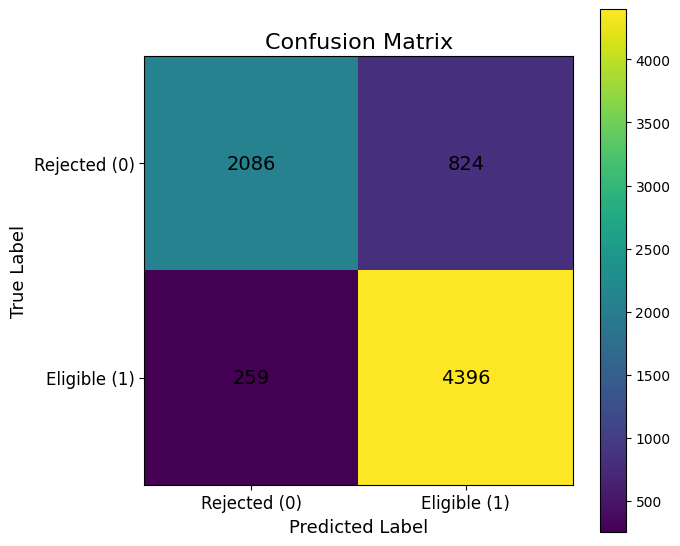

In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import numpy as np

# =========================
# METRICS
# =========================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# =========================
# PRINT SCORES
# =========================

print("\n==============================")
print(" MODEL PERFORMANCE")
print("==============================\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================

print("\n==============================")
print(" CLASSIFICATION REPORT")
print("==============================\n")

print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm)

# Labels
classes = ["Rejected (0)", "Eligible (1)"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, fontsize=12)
ax.set_yticklabels(classes, fontsize=12)

# Axis titles
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)

# Title
ax.set_title("Confusion Matrix", fontsize=16)

# Add values inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

# Colorbar
fig.colorbar(im)

plt.tight_layout()
plt.show()

In [20]:
importance_df = pd.DataFrame({

    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
53,Category_F.W./X/OP,0.038623
25,Branch_CSE,0.029048
40,Branch_IT,0.024122
95,Domicile_AI,0.023129
75,Category_SC/X/OP,0.019586
...,...,...
72,Category_SC/S/F,0.003074
52,Category_EWS/X/M,0.003005
50,Category_EWS/S/M,0.000000
59,Category_OBC/D/OP,0.000000


In [21]:
import joblib

joblib.dump(
    model,
    "../backend/app/models/xgb_model.pkl"
)

print("✅ Model saved")

✅ Model saved
